# PTGP Demo

Test all three models (GP, VFE, SVGP) on synthetic 1D regression data using PyMC priors.

In [1]:
import numpy as np
import pymc as pm
import preliz as pz
import pytensor
import pytensor.tensor as pt
import matplotlib.pyplot as plt

import ptgp as pg

## Generate data, student-t noise

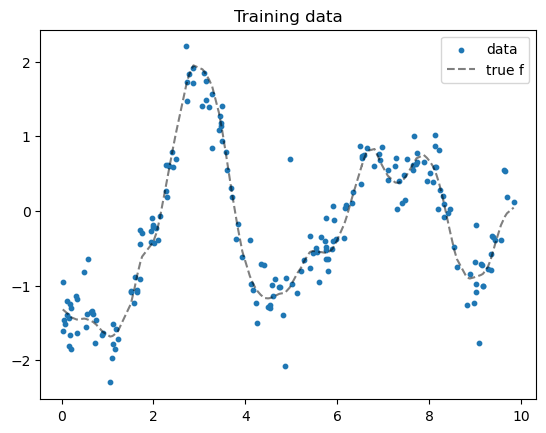

In [2]:
rng = np.random.default_rng(600)
N = 200
noise_std = 0.2
nu_true = 6

# True GP hyperparameters
eta_true = 1.3
ls_true = 1.0

X_train = np.sort(rng.uniform(0, 10, N))[:, None]
X_test = np.linspace(-1, 11, 200)[:, None]

# Draw from a GP prior with Matern-5/2 kernel
K = eta_true**2 * pg.kernels.Matern52(input_dim=1, ls=ls_true)
K = K(X_train, X_train).eval() + 1e-6 * np.eye(N)

f_train = rng.multivariate_normal(np.zeros(N), K)
y_train = f_train + noise_std * rng.standard_t(df=nu_true, size=N)

plt.scatter(X_train, y_train, s=10, label="data")
plt.plot(X_train, f_train, "k--", alpha=0.5, label="true f")
plt.legend()
plt.title("Training data");

## Exact GP

In [3]:
import time
import scipy.optimize

# Data is 1-D (D=1); batch dim is None to allow any N.
X_var = pt.matrix("X", shape=(None, 1))
y_var = pt.vector("y", shape=(None,))

with pm.Model() as gp_model:
    ls = pm.HalfFlat("ls")
    eta = pm.Exponential("eta", scale=2.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    kernel = eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls)
    gp = pg.gp.Unapproximated(kernel=kernel, sigma=sigma)

    fun, theta0, unpack_to_shared, shared_params, shared_extras = pg.optim.compile_scipy_objective(
        pg.objectives.marginal_log_likelihood, gp, X_var, y_var,
    )

t0 = time.time()
result = scipy.optimize.minimize(
    fun, theta0, args=(X_train, y_train), jac=True, method="L-BFGS-B",
)
elapsed = time.time() - t0
unpack_to_shared(result.x)
print(f"converged in {result.nit} iterations, loss = {result.fun:.4f}, time = {elapsed:.2f}s")

params = pg.optim.get_trained_params(gp_model, shared_params)
print(f"\nRecovered: {params}")
print(f"True:      eta={eta_true}, ls={ls_true}, noise_std={noise_std}")

/Users/bill/miniconda3/envs/ptgp/lib/python3.14/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


converged in 12 iterations, loss = 78.2431, time = 6.71s



Recovered: {'ls': 0.9194244467773754, 'eta': 1.0921237339716912, 'sigma': 0.2908216877170262}
True:      eta=1.3, ls=1.0, noise_std=0.2


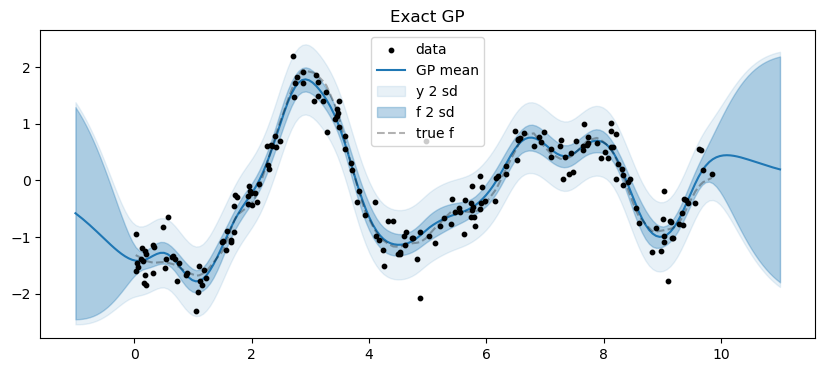

In [4]:
X_new_var = pt.matrix("X_new", shape=(None, 1))
predict_gp = pg.optim.compile_predict(
    gp, X_new_var, gp_model, shared_params,
    X_train=X_train, y_train=y_train,
)
predict_gp_y = pg.optim.compile_predict(
    gp, X_new_var, gp_model, shared_params,
    X_train=X_train, y_train=y_train, incl_lik=True,
)

mu_gp, var_gp = predict_gp(X_test)
_, var_gp_y = predict_gp_y(X_test)
sd_gp = np.sqrt(var_gp)
sd_gp_y = np.sqrt(var_gp_y)

plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, s=10, c="k", zorder=3, label="data")
plt.plot(X_test, mu_gp, "C0", label="GP mean")
plt.fill_between(X_test.ravel(), mu_gp - 2*sd_gp_y, mu_gp + 2*sd_gp_y, alpha=0.1, color="C0", label="y 2 sd")
plt.fill_between(X_test.ravel(), mu_gp - 2*sd_gp, mu_gp + 2*sd_gp, alpha=0.3, color="C0", label="f 2 sd")
plt.plot(X_train, f_train, "k--", alpha=0.3, label="true f")
plt.legend()
plt.title("Exact GP");

## VFE (Sparse GP -- collapsed bound)

In [5]:
M = 20
Z_init = np.linspace(-0.5, 10.5, M)[:, None]

# Inducing points: M is known (20), D=1.
Z_var = pt.matrix("Z", shape=(M, 1))

with pm.Model() as vfe_model:
    ls = pm.HalfFlat("ls")
    eta = pm.Exponential("eta", lam=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    vfe = pg.gp.VFE(
        kernel=eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls),
        sigma=sigma,
        inducing_variable=pg.inducing.Points(Z_var),
    )

fun_vfe, theta0_vfe, unpack_to_shared_vfe, shared_params_vfe, shared_extras_vfe = pg.optim.compile_scipy_objective(
    pg.objectives.collapsed_elbo, vfe, X_var, y_var,
    model=vfe_model,
    extra_vars=[Z_var],
    extra_init=[Z_init],
)

t0 = time.time()
result_vfe = scipy.optimize.minimize(
    fun_vfe, theta0_vfe, args=(X_train, y_train), jac=True, method="L-BFGS-B",
)
elapsed = time.time() - t0
unpack_to_shared_vfe(result_vfe.x)
print(f"converged in {result_vfe.nit} iterations, loss = {result_vfe.fun:.4f}, time = {elapsed:.2f}s")

params_vfe = pg.optim.get_trained_params(vfe_model, shared_params_vfe)
print(f"\nRecovered: {params_vfe}")
print(f"True:      eta={eta_true}, ls={ls_true}, noise_std={noise_std}")

/Users/bill/miniconda3/envs/ptgp/lib/python3.14/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


converged in 61 iterations, loss = 80.8473, time = 9.82s



Recovered: {'ls': 1.081011357553312, 'eta': 1.1351663625734516, 'sigma': 0.2981827821912192}
True:      eta=1.3, ls=1.0, noise_std=0.2


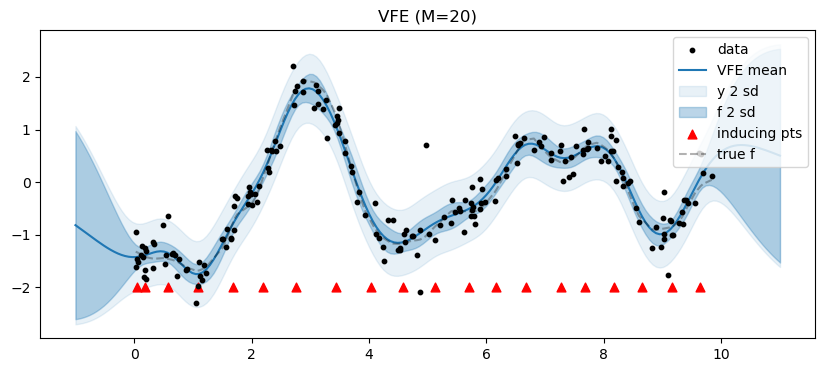

In [6]:
predict_vfe = pg.optim.compile_predict(
    vfe, X_new_var, vfe_model, shared_params_vfe,
    X_train=X_train, y_train=y_train,
    extra_vars=[Z_var],
    shared_extras=shared_extras_vfe,
)
predict_vfe_y = pg.optim.compile_predict(
    vfe, X_new_var, vfe_model, shared_params_vfe,
    X_train=X_train, y_train=y_train,
    extra_vars=[Z_var],
    shared_extras=shared_extras_vfe, incl_lik=True,
)

mu_vfe, var_vfe = predict_vfe(X_test)
_, var_vfe_y = predict_vfe_y(X_test)
sd_vfe = np.sqrt(var_vfe)
sd_vfe_y = np.sqrt(var_vfe_y)

Z_final = shared_extras_vfe[0].get_value()

plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, s=10, c="k", zorder=3, label="data")
plt.plot(X_test, mu_vfe, "C0", label="VFE mean")
plt.fill_between(X_test.ravel(), mu_vfe - 2*sd_vfe_y, mu_vfe + 2*sd_vfe_y, alpha=0.1, color="C0", label="y 2 sd")
plt.fill_between(X_test.ravel(), mu_vfe - 2*sd_vfe, mu_vfe + 2*sd_vfe, alpha=0.3, color="C0", label="f 2 sd")
plt.scatter(Z_final, np.zeros(M) - 2, marker="^", c="r", s=40, label="inducing pts")
plt.plot(X_train, f_train, "k--", alpha=0.3, label="true f")
plt.legend(loc="upper right")
plt.title(f"VFE (M={M})");

## SVGP (Stochastic Variational GP)

Minibatch training with variational parameters.

In [7]:
M_svgp = 20

Z_init_kernel = pg.kernels.Matern52(input_dim=1, ls=1.0)
Z_greedy = pg.inducing.greedy_variance_init(X_train, M_svgp, Z_init_kernel, rng=42).Z

vp = pg.gp.init_variational_params(M_svgp)
Z_var = pt.matrix("Z", shape=(M_svgp, 1))

with pm.Model() as svgp_model:
    ls = pm.HalfFlat("ls")
    eta = pm.Exponential("eta", lam=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    nu = pm.Gamma("nu", alpha=2, beta=0.1)

    kernel = eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls)
    lik = pg.likelihoods.StudentT(sigma=sigma, nu=nu)

    svgp = pg.gp.SVGP(
        kernel=kernel, likelihood=lik,
        inducing_variable=pg.inducing.Points(Z_var),
        variational_params=vp,
    )

### Training strategy

**Inducing point init.** `greedy_variance_init` picks a space-filling subset of `X_train` via pivoted Cholesky (Burt et al. 2020). It's a strong enough starting point that `Z` often doesn't need further optimization — but here we still fine-tune it in phase 2 to demonstrate the mechanics.

**Two-phase training.** `svgp` is built once with `Z_var` as a symbolic placeholder. Phase 1 pins `Z_var` to `Z_greedy` via `frozen_vars` and trains only the hyperparameters and variational parameters. Phase 2 moves `Z_var` into `extra_vars`, making `Z` trainable, and recompiles using the state carried over from phase 1.

**Learning rates.** Phase 1 runs a single exponential-decay schedule from `1e-2` down to `5e-3` over `n_phase1` steps. Phase 2 uses per-group rates:

- `hyp` — fixed at 50% of phase 1's final LR (gentle fine-tuning once hyperparameters are near optimum).
- `var` — continues phase 1's decay seamlessly, starting at `5e-3`.
- `Z` — its own small steady rate (`5e-3`) for the newly unfrozen inducing points.

In [8]:
X_batch_var = pt.matrix("X_batch", shape=(None, 1))
y_batch_var = pt.vector("y_batch", shape=(None,))
batch_size = 32
n_phase1 = 1000
n_phase2 = 1000

def elbo_scaled(model, X, y):
    return pg.objectives.elbo(model, X, y, n_data=N)

# ----- Phase 1: Z frozen -----
phase1_base_lr = 1e-2
phase1_decay_rate = 0.5
phase1_final_lr = phase1_base_lr * phase1_decay_rate  # LR at t=n_phase1

train_step_1, shared_params_1, shared_extras_1 = pg.optim.compile_training_step(
    elbo_scaled, svgp, X_batch_var, y_batch_var,
    model=svgp_model,
    extra_vars=vp.extra_vars,
    extra_init=vp.extra_init,
    frozen_vars={Z_var: Z_greedy},
    learning_rate=pg.optim.schedules.exponential_decay(
        phase1_base_lr, decay_rate=phase1_decay_rate, decay_steps=n_phase1,
    ),
)

losses = []
t0 = time.time()
for step in range(n_phase1):
    idx = rng.choice(N, size=batch_size, replace=False)
    loss = train_step_1(X_train[idx], y_train[idx])
    losses.append(float(loss))
    if step % 250 == 0:
        print(f"[phase 1, Z frozen]    Step {step}: loss = {loss:.2f}")
elapsed_1 = time.time() - t0

# ----- Phase 2: Z trainable, per-group LRs -----
hyp_value_vars = [svgp_model.rvs_to_values[rv] for rv in (ls, eta, sigma, nu)]
phase2_hyp_lr = 0.5 * phase1_final_lr

train_step_2, shared_params_svgp, shared_extras_svgp = pg.optim.compile_training_step(
    elbo_scaled, svgp, X_batch_var, y_batch_var,
    model=svgp_model,
    extra_vars=[*vp.extra_vars, Z_var],
    extra_init=[*vp.extra_init, Z_greedy],
    param_groups={
        "hyp": hyp_value_vars,
        "var": vp.extra_vars,
        "Z":   [Z_var],
    },
    learning_rate={
        "hyp": phase2_hyp_lr,
        "var": pg.optim.schedules.exponential_decay(
            phase1_final_lr, decay_rate=phase1_decay_rate, decay_steps=n_phase1,
        ),
        "Z":   5e-3,
    },
)

# Carry phase-1 state into phase 2 (q_mu, q_sqrt_flat shared values).
for vv, sh1 in shared_params_1.items():
    shared_params_svgp[vv].set_value(sh1.get_value())
for sh2, sh1 in zip(shared_extras_svgp[: len(vp.extra_vars)], shared_extras_1):
    sh2.set_value(sh1.get_value())

t0 = time.time()
for step in range(n_phase2):
    idx = rng.choice(N, size=batch_size, replace=False)
    loss = train_step_2(X_train[idx], y_train[idx])
    losses.append(float(loss))
    if step % 250 == 0:
        print(f"[phase 2, Z trainable] Step {step}: loss = {loss:.2f}")
elapsed_2 = time.time() - t0

params_svgp = pg.optim.get_trained_params(svgp_model, shared_params_svgp)
print(f"\nRecovered: {params_svgp}")
print(f"True:      eta={eta_true}, ls={ls_true}, noise_std={noise_std}, nu={nu_true}")
print(f"\ntraining time: phase 1 = {elapsed_1:.2f}s, phase 2 = {elapsed_2:.2f}s, total = {elapsed_1 + elapsed_2:.2f}s")

/Users/bill/miniconda3/envs/ptgp/lib/python3.14/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


/Users/bill/miniconda3/envs/ptgp/lib/python3.14/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


[phase 1, Z frozen]    Step 0: loss = 372.58
[phase 1, Z frozen]    Step 250: loss = 90.16
[phase 1, Z frozen]    Step 500: loss = 121.26
[phase 1, Z frozen]    Step 750: loss = 48.74


/Users/bill/miniconda3/envs/ptgp/lib/python3.14/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


/Users/bill/miniconda3/envs/ptgp/lib/python3.14/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


[phase 2, Z trainable] Step 0: loss = 33.01
[phase 2, Z trainable] Step 250: loss = 71.19
[phase 2, Z trainable] Step 500: loss = 105.35
[phase 2, Z trainable] Step 750: loss = 27.46



Recovered: {'ls': 0.9692881628265252, 'eta': 0.9036024343044534, 'sigma': 0.23119834947657272, 'nu': 5.419908380037656}
True:      eta=1.3, ls=1.0, noise_std=0.2, nu=6

training time: phase 1 = 10.96s, phase 2 = 11.37s, total = 22.33s


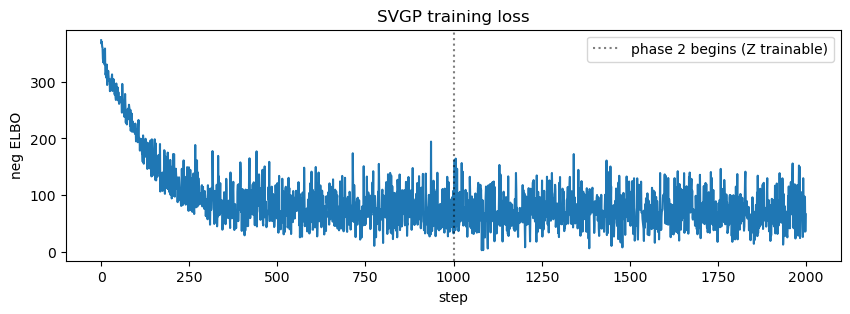

In [9]:
plt.figure(figsize=(10, 3))
plt.plot(losses)
plt.axvline(n_phase1, color="k", linestyle=":", alpha=0.5, label="phase 2 begins (Z trainable)")
plt.xlabel("step")
plt.ylabel("neg ELBO")
plt.legend()
plt.title("SVGP training loss");

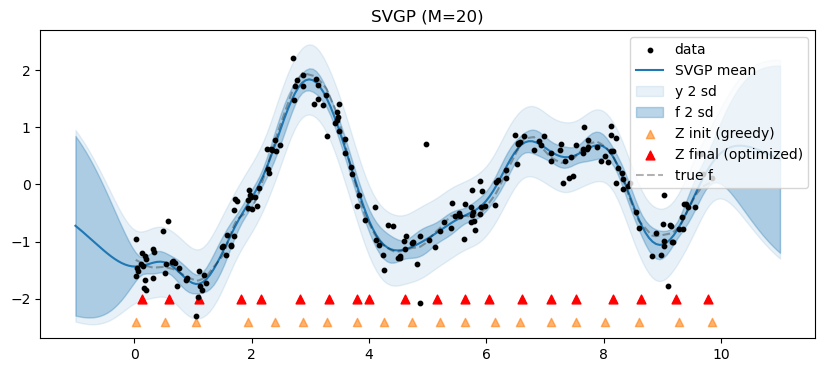

In [10]:
predict_svgp = pg.optim.compile_predict(
    svgp, X_new_var, svgp_model, shared_params_svgp,
    extra_vars=[*vp.extra_vars, Z_var],
    shared_extras=shared_extras_svgp,
)
predict_svgp_y = pg.optim.compile_predict(
    svgp, X_new_var, svgp_model, shared_params_svgp,
    extra_vars=[*vp.extra_vars, Z_var],
    shared_extras=shared_extras_svgp, incl_lik=True,
)

mu_svgp, var_svgp = predict_svgp(X_test)
mu_svgp_y, var_svgp_y = predict_svgp_y(X_test)
sd_svgp = np.sqrt(var_svgp)
sd_svgp_y = np.sqrt(var_svgp_y)

plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, s=10, c="k", zorder=3, label="data")
plt.plot(X_test, mu_svgp, "C0", label="SVGP mean")
plt.fill_between(X_test.ravel(), mu_svgp_y - 2*sd_svgp_y, mu_svgp_y + 2*sd_svgp_y, alpha=0.1, color="C0", label="y 2 sd")
plt.fill_between(X_test.ravel(), mu_svgp - 2*sd_svgp, mu_svgp + 2*sd_svgp, alpha=0.3, color="C0", label="f 2 sd")
Z_opt = shared_extras_svgp[len(vp.extra_vars)].get_value()
plt.scatter(Z_greedy.ravel(), np.zeros(M_svgp) - 2.4, marker="^", c="C1", s=35, alpha=0.6, label="Z init (greedy)")
plt.scatter(Z_opt.ravel(), np.zeros(M_svgp) - 2.0, marker="^", c="r", s=40, label="Z final (optimized)")
plt.plot(X_train, f_train, "k--", alpha=0.3, label="true f")
plt.legend(loc="upper right")
plt.title(f"SVGP (M={M_svgp})");

## Comparison

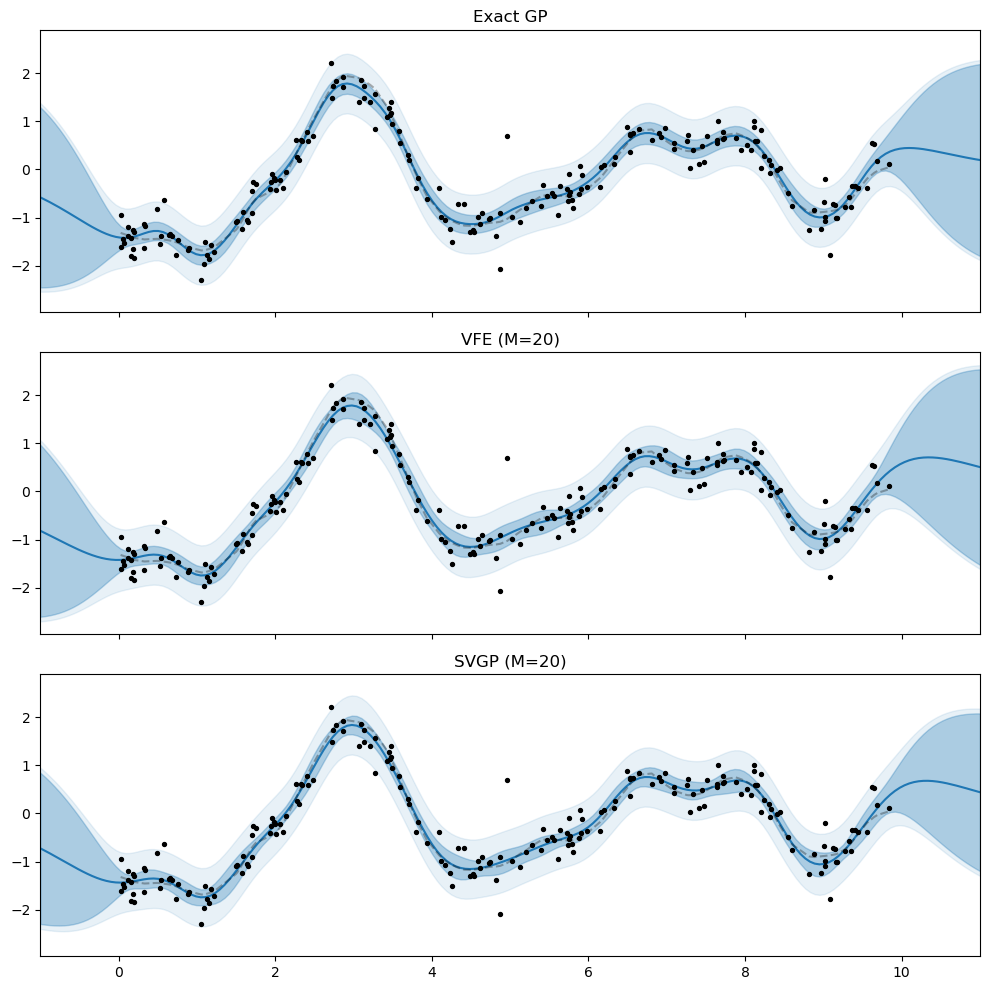

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, sharey=True)

for ax, (mu, sd_f, sd_y, title) in zip(axes, [
    (mu_gp, sd_gp, sd_gp_y, "Exact GP"),
    (mu_vfe, sd_vfe, sd_vfe_y, f"VFE (M={M})"),
    (mu_svgp, sd_svgp, sd_svgp_y, f"SVGP (M={M_svgp})"),
]):
    ax.scatter(X_train, y_train, s=8, c="k", zorder=3)
    ax.plot(X_test, mu, "C0")
    ax.fill_between(X_test.ravel(), mu - 2*sd_y, mu + 2*sd_y, alpha=0.1, color="C0")
    ax.fill_between(X_test.ravel(), mu - 2*sd_f, mu + 2*sd_f, alpha=0.3, color="C0")
    ax.plot(X_train, f_train, "k--", alpha=0.3)
    ax.set_title(title)
    ax.set_xlim(-1, 11)

fig.tight_layout();